#  Heart Disease Prediction — Model Training & Deployment


 Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)



In [3]:
data = pd.read_csv(r"C:\Users\user\Downloads\heart disease.csv\HeartDiseaseTrain-Test.csv")   # <-- change to your filename
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


##  Exploratory Data Analysis (EDA)

In [4]:
data.isna().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [5]:
data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='str')

In [6]:
data.shape

(1025, 14)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   str    
 2   chest_pain_type                1025 non-null   str    
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   str    
 6   rest_ecg                       1025 non-null   str    
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   str    
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   str    
 11  vessels_colored_by_flourosopy  1025 non-null   str    
 12  thalassemia                    1025 non-null   str    
 13 

In [8]:
# Remove duplicates
data.drop_duplicates(inplace=True)


##  Data Visualization

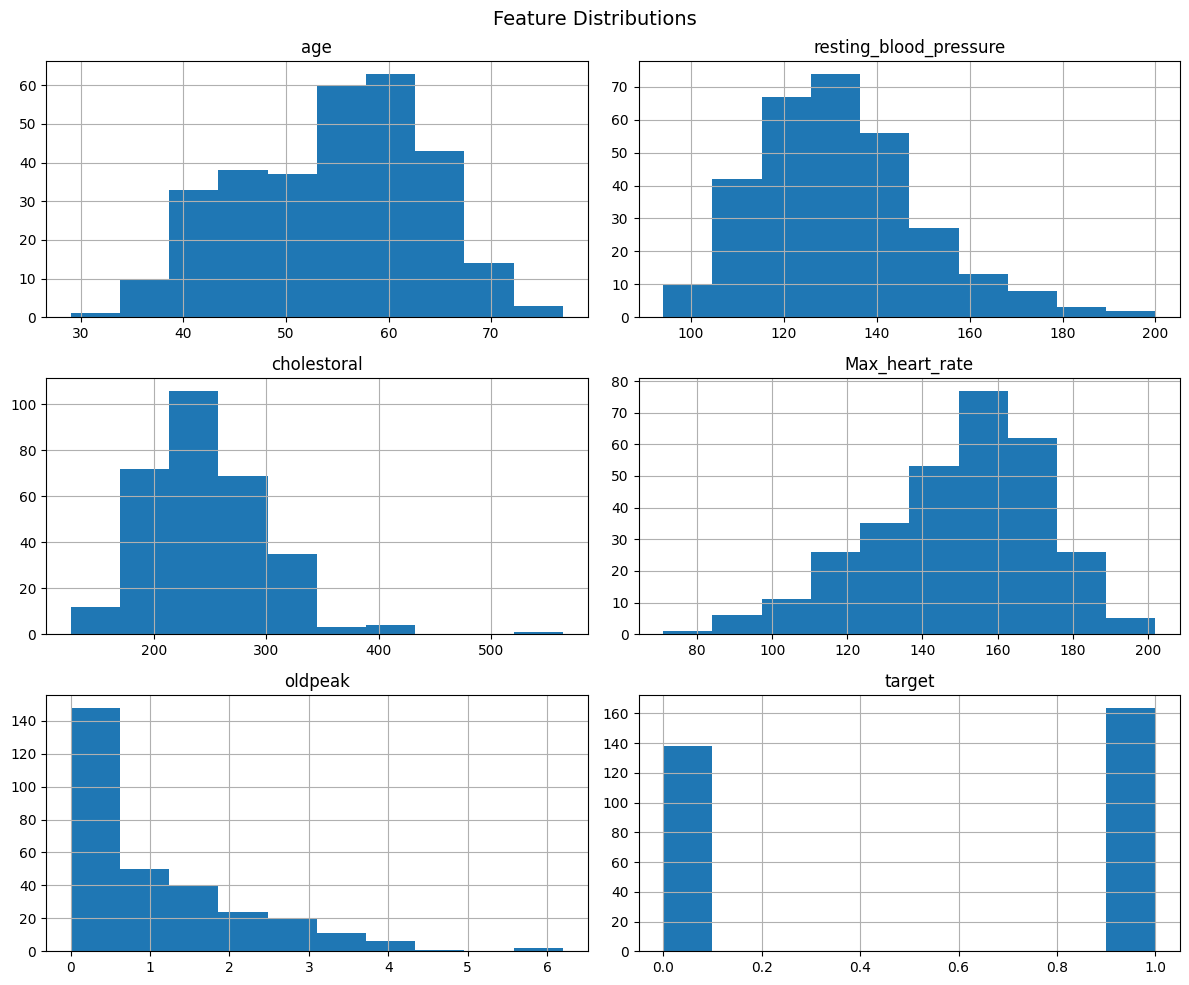

In [9]:
# Histograms
data.hist(figsize=(12, 10))
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

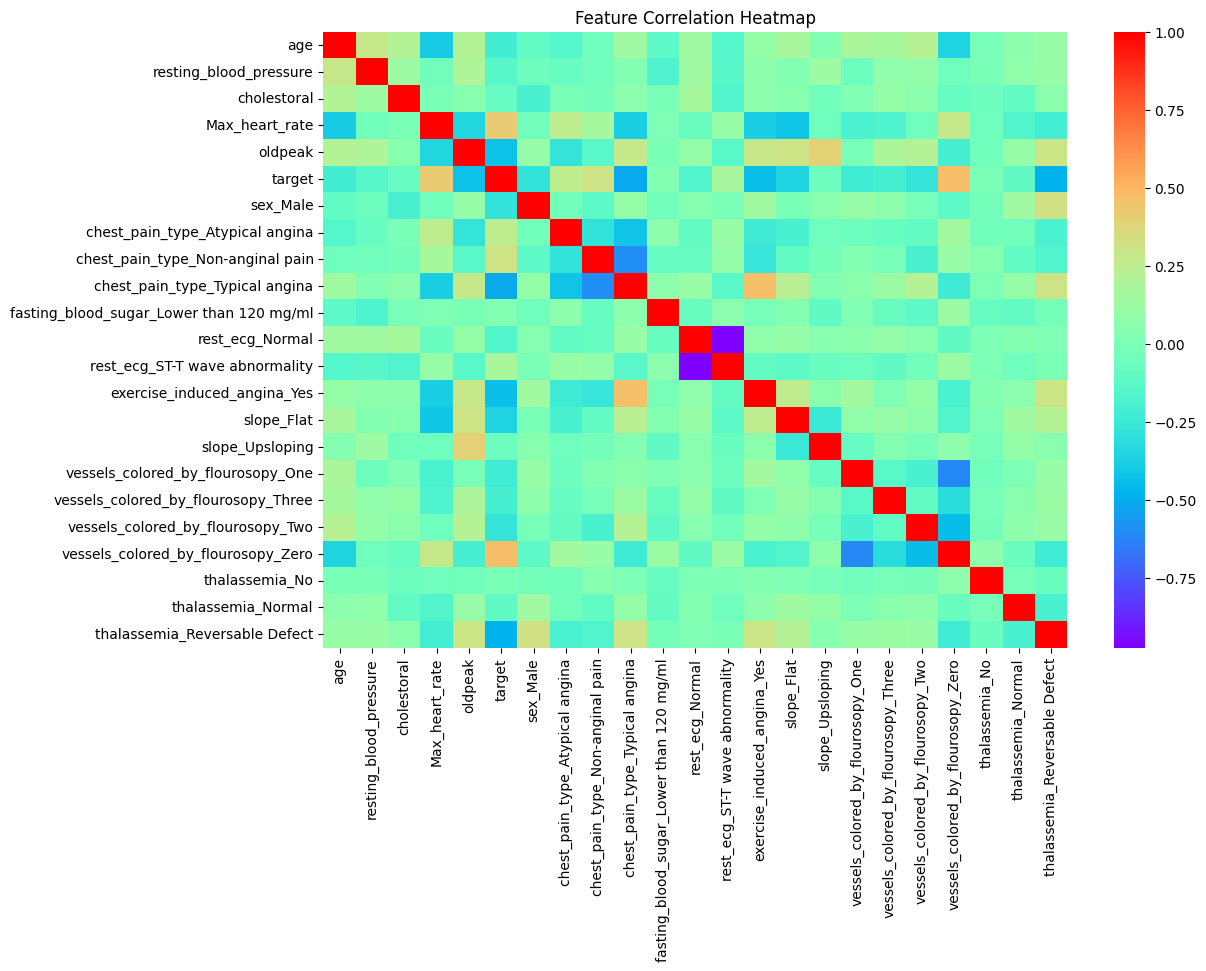

In [10]:
# Correlation heatmap
data_encoded_viz = pd.get_dummies(data, drop_first=True)   # only for visualization
plt.figure(figsize=(12, 8))
sns.heatmap(data_encoded_viz.corr(), cmap='rainbow', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

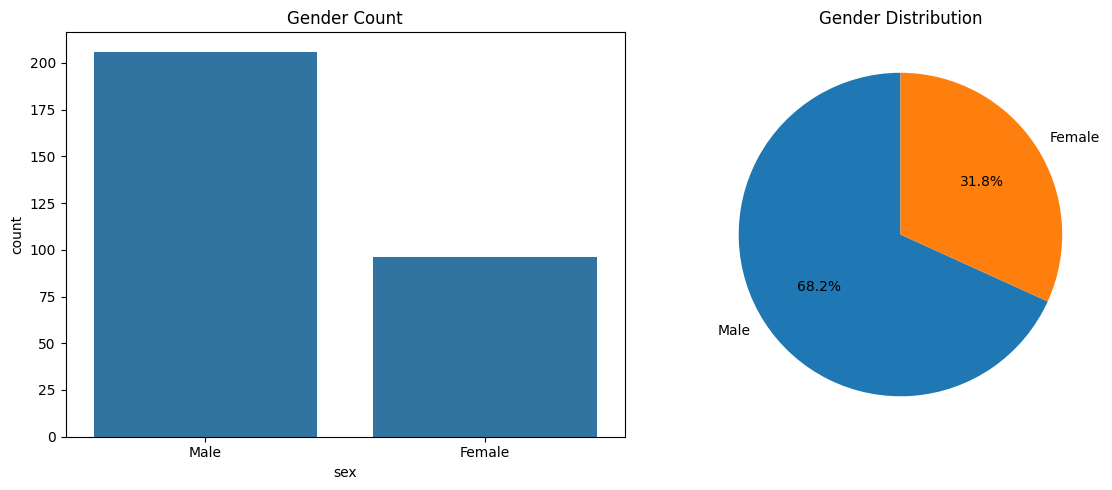

In [11]:
# Gender distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='sex', data=data)
plt.title('Gender Count')

plt.subplot(1, 2, 2)
a = data['sex'].value_counts()
plt.pie(a.values, labels=a.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()

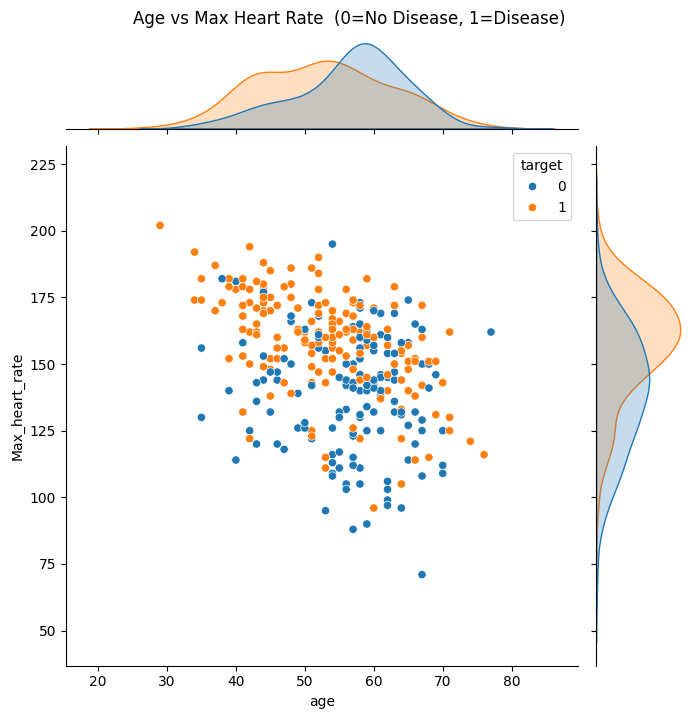

In [12]:
# Age vs Max Heart Rate by target
sns.jointplot(
    data=data,
    x='age',
    y='Max_heart_rate',
    hue='target',
    kind='scatter',
    height=7
)
plt.suptitle('Age vs Max Heart Rate  (0=No Disease, 1=Disease)', y=1.02)
plt.show()

##  Encode Categorical Columns


In [13]:
categorical_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',               #We use **LabelEncoder** only — no `get_dummies`.  
                                         #This keeps the feature count at **13**, making train and predict pipelines consistent.
    'rest_ecg',
    'exercise_induced_angina',
    'slope',
    'vessels_colored_by_flourosopy',
    'thalassemia'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,1,2,168,0,1.0,0,3,3,0
1,53,1,3,140,203,0,1,155,1,3.1,2,4,3,0
2,70,1,3,145,174,1,2,125,1,2.6,2,4,3,0
3,61,1,3,148,203,1,2,161,0,0.0,0,1,3,0
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0,0


## Separate X and y

In [14]:
X = data.drop('target', axis=1)   # 13 features
y = data['target']

##  Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [16]:
X_train

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
182,60,1,3,140,293,1,1,170,0,1.2,1,3,3
288,58,0,2,120,340,1,2,172,0,0.0,0,4,0
652,66,0,0,150,226,1,2,114,0,2.6,2,4,0
541,44,1,2,140,235,1,1,180,0,0.0,0,4,0
20,60,1,2,140,185,1,1,155,0,3.0,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,61,1,2,150,243,0,2,137,1,1.0,1,4,0
431,65,0,3,150,225,1,1,114,0,1.0,1,2,3
78,52,1,1,134,201,1,2,158,0,0.8,0,1,0
366,58,1,2,112,230,1,1,165,0,2.5,1,1,3


In [17]:
X_test

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
233,41,0,1,126,306,1,2,163,0,0.0,0,4,0
101,57,1,2,150,126,0,2,173,0,0.2,0,1,3
215,49,1,1,130,266,1,2,171,0,0.6,0,4,0
377,64,0,3,130,303,1,2,122,0,2.0,1,3,0
131,51,0,2,130,256,1,1,149,0,0.5,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,54,1,3,110,206,1,1,108,1,0.0,1,1,0
135,58,0,3,170,225,0,1,146,1,2.8,1,3,2
36,51,1,0,125,213,1,1,125,1,1.4,0,1,0
256,35,0,3,138,183,1,2,182,0,1.4,0,4,0


##  Scaleing (StandardScaler on 13 features)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test


In [19]:
k=KNeighborsClassifier(n_neighbors=5)
s=SVC(kernel='rbf')
g=GaussianNB()
d=DecisionTreeClassifier(criterion='entropy')
r=RandomForestClassifier(random_state=1)
a=AdaBoostClassifier()
x=XGBClassifier()
gr=GradientBoostingClassifier()
lists=[]
l=[k,s,g,d,r,a,x,gr]
for i in l:
  print(i)
  i.fit(X_train,y_train)
  y_pred=i.predict(X_test)
  lists.append(accuracy_score(y_test,y_pred)*100)
  print(accuracy_score(y_test,y_pred)*100)

KNeighborsClassifier()
68.13186813186813
SVC()
71.42857142857143
GaussianNB()
82.41758241758241
DecisionTreeClassifier(criterion='entropy')
75.82417582417582
RandomForestClassifier(random_state=1)
86.81318681318682
AdaBoostClassifier()
80.21978021978022
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_t

In [20]:
lists = lists[:7]
data1 = pd.DataFrame(lists, index=['KNN','SVC','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'], columns=['hyperparameter'])
data1

,hyperparameter
KNN,68.131868
SVC,71.428571
DECISIONTREE,82.417582
RANDOMFOREST,75.824176
ADABOOST,86.813187
XGB,80.219780
GRADIENT,81.318681


## Tune AdaBoost with GridSearchCV

In [21]:
param_grid = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1, 1.5]
}

grid_model = GridSearchCV(
    AdaBoostClassifier(random_state=1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_model.fit(X_train_scaled, y_train)

print('Best params :', grid_model.best_params_)
print('Best CV acc :', round(grid_model.best_score_ * 100, 2), '%')

Best params : {'learning_rate': 0.01, 'n_estimators': 200}
Best CV acc : 84.83 %


In [22]:
y_pred = grid_model.predict(X_test_scaled)

print('Test Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print(classification_report(y_test, y_pred))

Test Accuracy: 84.62 %

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        36
           1       0.90      0.84      0.87        55

    accuracy                           0.85        91
   macro avg       0.84      0.85      0.84        91
weighted avg       0.85      0.85      0.85        91



## Confusion Matrix

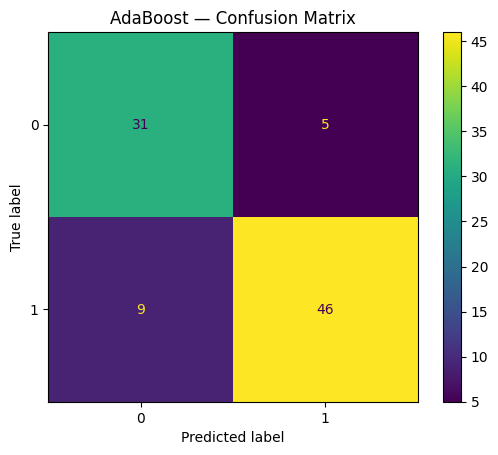

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('AdaBoost — Confusion Matrix')
plt.show()

##  ROC Curve

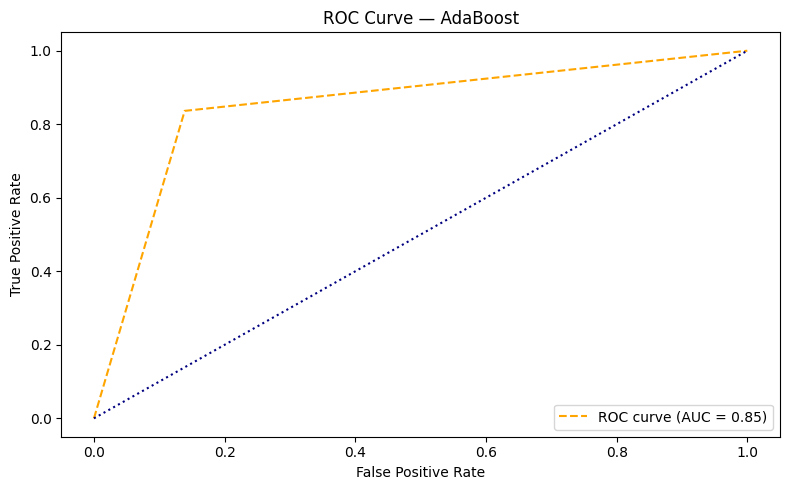

AUC Score: 0.8487


In [24]:
auc_score = roc_auc_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linestyle='--', color='orange',
         label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle=':')
plt.title('ROC Curve — AdaBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('AUC Score:', round(auc_score, 4))

##  Test with Sample Input

In [25]:
# Sample patient (replace values with real input to test)
sample = pd.DataFrame([{
    'age':                           63,
    'sex':                            1,
    'chest_pain_type':                3,
    'resting_blood_pressure':       145,
    'cholestoral':                  233,
    'fasting_blood_sugar':            1,
    'rest_ecg':                       0,
    'Max_heart_rate':               150,
    'exercise_induced_angina':        0,
    'oldpeak':                      2.3,
    'slope':                          0,
    'vessels_colored_by_flourosopy':  0,
    'thalassemia':                    1,
}])

# Align columns to training order
sample = sample[list(X.columns)]
sample_scaled = scaler.transform(sample)

prediction = grid_model.predict(sample_scaled)[0]
proba      = grid_model.predict_proba(sample_scaled)[0]

print('Prediction :', 'Heart Disease' if prediction == 1 else 'No Heart Disease')
print('Risk Score :', round(proba[1] * 100, 2), '%')

Prediction : No Heart Disease
Risk Score : 13.7 %


In [26]:
# Save the tuned AdaBoost model
pickle.dump(grid_model, open('heart_disease_model.save', 'wb'))

# Save the scaler (fit on 13 features)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save the exact column order used during training
pickle.dump(list(X.columns), open('feature_columns.pkl', 'wb'))

